# 01 — Audio Loading And Basic Plots

Stage 1 proves the loop: audio file in, trustworthy plots out. The target track for this stage is The Weeknd's "Tears In The Rain", expected locally at `data/tracks/the-weeknd-tears-in-the-rain.wav`.

Audio files are intentionally gitignored. If the local track is missing, this notebook uses a short synthetic pulse demo so the code and plots remain executable; those fallback plots are not a substitute for validating the real target track.

In [1]:
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np

PROJECT_ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
SRC_ROOT = PROJECT_ROOT / "src"
if str(SRC_ROOT) not in sys.path:
    sys.path.insert(0, str(SRC_ROOT))

from audio.config import DEFAULT_AUDIO_CONFIG  # noqa: E402
from audio.features import basic_feature_frame  # noqa: E402
from audio.loader import load_audio  # noqa: E402
from viz.plots import (  # noqa: E402
    plot_feature_against_waveform,
    plot_spectrogram,
    plot_waveform,
)

plt.style.use("dark_background")
TRACK_PATH = PROJECT_ROOT / "data" / "tracks" / "the-weeknd-tears-in-the-rain.wav"
TRACK_NAME = "The Weeknd - Tears In The Rain"


## Load Audio

The loader is the only place where source audio becomes a project analysis array. It resamples to the shared project sample rate so every downstream feature uses the same timing grid.

In [2]:
def make_synthetic_demo(sample_rate: int) -> np.ndarray:
    duration_seconds = 24.0
    times = np.arange(int(sample_rate * duration_seconds)) / sample_rate
    rng = np.random.default_rng(7)

    bass = 0.22 * np.sin(2 * np.pi * 55.0 * times)
    pad_vibrato = 0.6 * np.sin(2 * np.pi * 0.08 * times)
    pad = 0.12 * np.sin(2 * np.pi * 220.0 * times + pad_vibrato)
    air = 0.025 * rng.normal(size=times.shape)

    beat_times = np.arange(0.5, duration_seconds, 0.6)
    kick = np.zeros_like(times)
    for beat_time in beat_times:
        envelope = np.exp(-60.0 * np.maximum(times - beat_time, 0.0))
        envelope[times < beat_time] = 0.0
        kick += 0.55 * envelope * np.sin(2 * np.pi * 62.0 * times)

    build = np.clip((times - 8.0) / 10.0, 0.0, 1.0)
    drop_gate = (times > 14.0).astype(float)
    synth = 0.16 * build * drop_gate * np.sin(2 * np.pi * 440.0 * times)

    samples = bass + pad + kick + synth + air
    samples = samples / np.max(np.abs(samples)) * 0.85
    return samples.astype(np.float32)

if TRACK_PATH.exists():
    samples, sample_rate = load_audio(TRACK_PATH)
    source_label = TRACK_NAME
else:
    samples = make_synthetic_demo(DEFAULT_AUDIO_CONFIG.sample_rate)
    sample_rate = DEFAULT_AUDIO_CONFIG.sample_rate
    source_label = "Synthetic fallback demo - replace with the target track"

print(source_label)
print(f"sample_rate: {sample_rate:,} Hz")
print(f"duration: {len(samples) / sample_rate:.2f} seconds")
print(f"samples: {len(samples):,}")


Synthetic fallback demo - replace with the target track
sample_rate: 44,100 Hz
duration: 24.00 seconds
samples: 1,058,400


## Waveform

The waveform is the macro pressure map. For the target track, this is where quiet passages, build pressure, and large transitions should be visible before any feature extractor gets trusted.

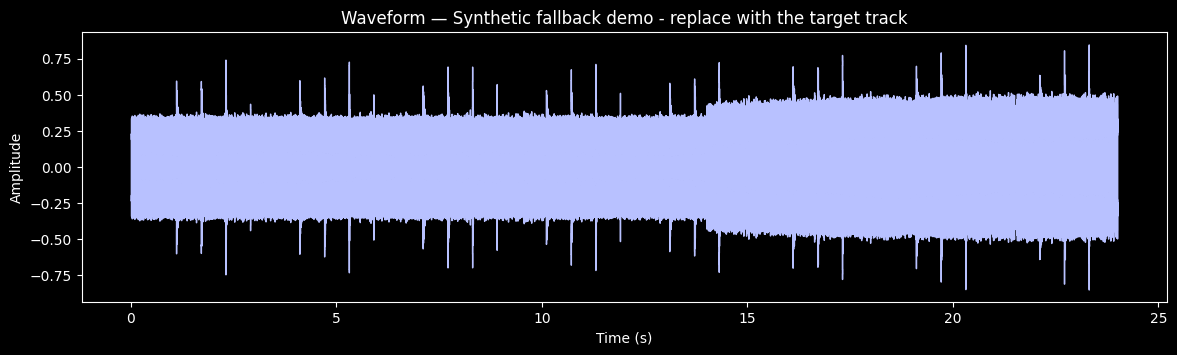

In [3]:
fig, ax = plt.subplots(figsize=(14, 3.5))
plot_waveform(samples, sample_rate, ax=ax)
ax.set_title(f"Waveform — {source_label}")
plt.show()

## Spectrogram

The spectrogram shows where energy lives by frequency over time. Musically, the low bands should expose bass and kick weight, while the upper bands should reveal air, noise, hats, and bright synth texture.

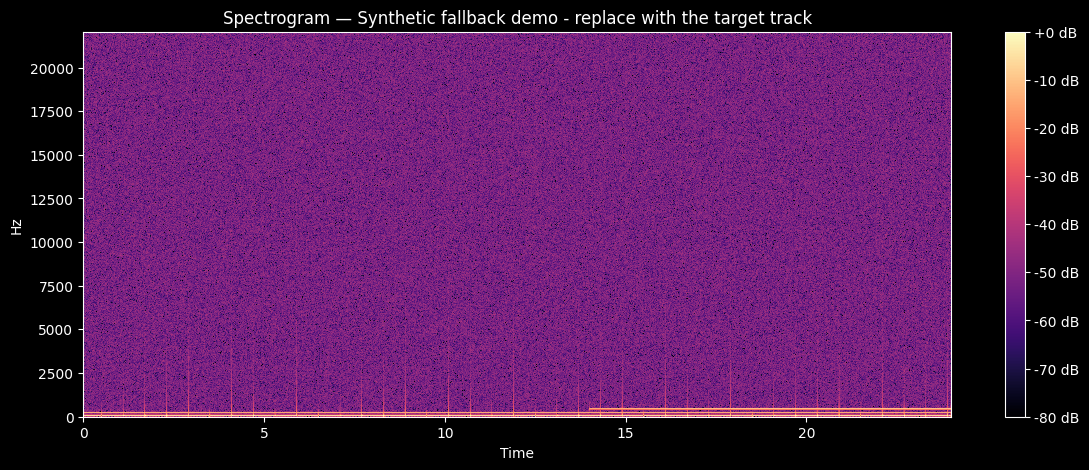

In [4]:
fig, ax = plt.subplots(figsize=(14, 5))
plot_spectrogram(samples, sample_rate, ax=ax)
ax.set_title(f"Spectrogram — {source_label}")
plt.show()

## Basic Frame Features

These are Stage 1 sanity-check features, not final musical understanding. The point is to plot them against the waveform and decide whether their movement matches what we can hear.

In [5]:
features = basic_feature_frame(samples, sample_rate)
features.head()

,time_seconds,rms,spectral_centroid_hz,spectral_flux,spectral_rolloff_hz
0,0.00000,0.114975,5912.364746,0.000000,15525.439453
1,0.01161,0.143704,6475.512207,0.440188,16192.968750
2,0.02322,0.163614,6942.956055,0.238658,16645.166016
3,0.03483,0.167508,7124.990234,0.201639,16795.898438
4,0.04644,0.168313,7119.615234,0.190367,16925.097656


## RMS Envelope

RMS tracks short-window energy. Musically, it should rise during denser or louder sections and fall during sparse sections; it is useful for pressure, but it should not be mistaken for beat or emotion by itself.

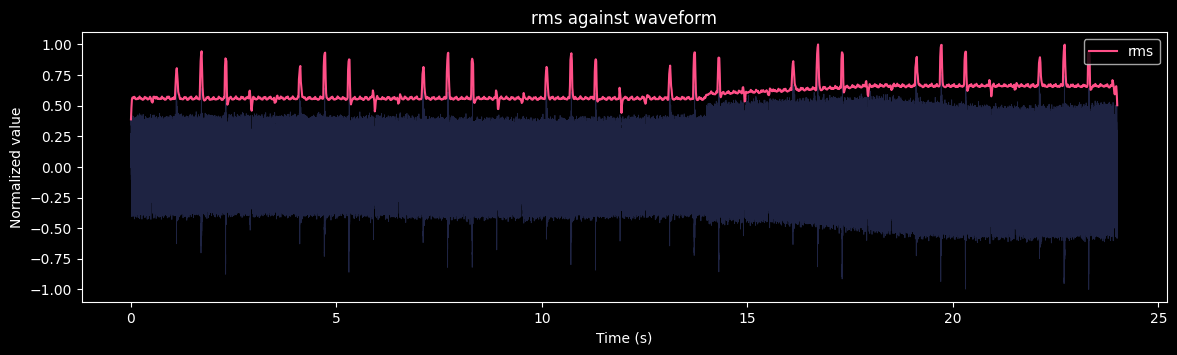

In [6]:
fig, ax = plt.subplots(figsize=(14, 3.5))
plot_feature_against_waveform(samples, sample_rate, features, "rms", ax=ax)
plt.show()

## Spectral Centroid

Spectral centroid tracks brightness. In musical terms, it should lift when brighter synths, hats, noise, or distorted upper harmonics enter, even if the overall loudness does not change much.

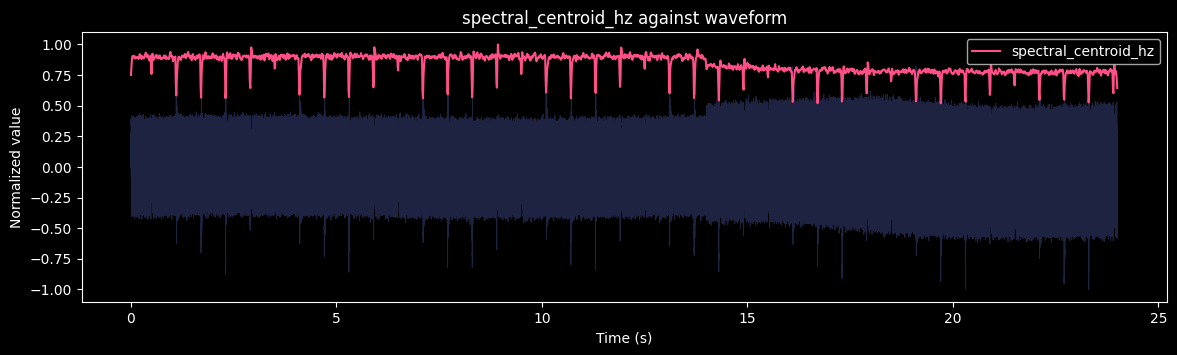

In [7]:
fig, ax = plt.subplots(figsize=(14, 3.5))
plot_feature_against_waveform(
    samples, sample_rate, features, "spectral_centroid_hz", ax=ax
)
plt.show()


## Spectral Flux

Spectral flux tracks frame-to-frame spectral change. On the real target track, useful peaks should line up with kick hits, snare or clap attacks, and new instrument entries; if the peaks do not match those perceived events, Stage 2 onset work should fix that rather than pretending this curve is enough.

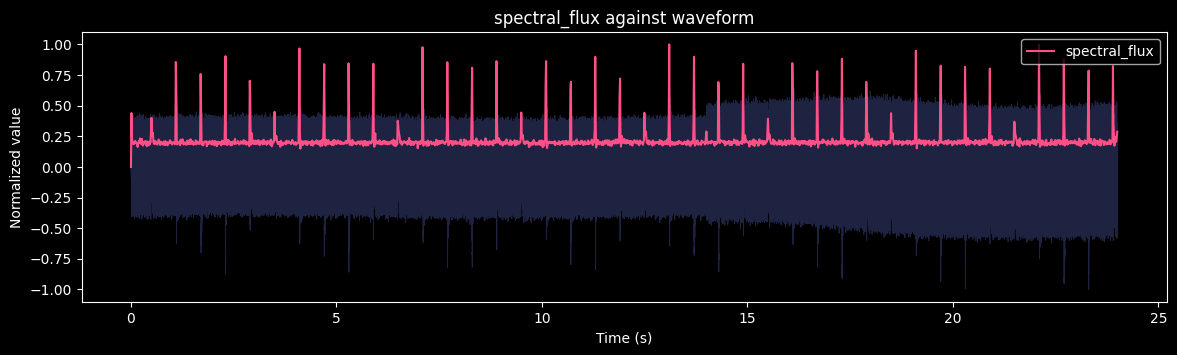

In [8]:
fig, ax = plt.subplots(figsize=(14, 3.5))
plot_feature_against_waveform(samples, sample_rate, features, "spectral_flux", ax=ax)
plt.show()

## Spectral Rolloff

Spectral rolloff tracks how far the upper-frequency energy spreads. Musically, it helps separate dark, low-heavy passages from sections with more air, distortion, percussion brightness, or wide synth sheen.

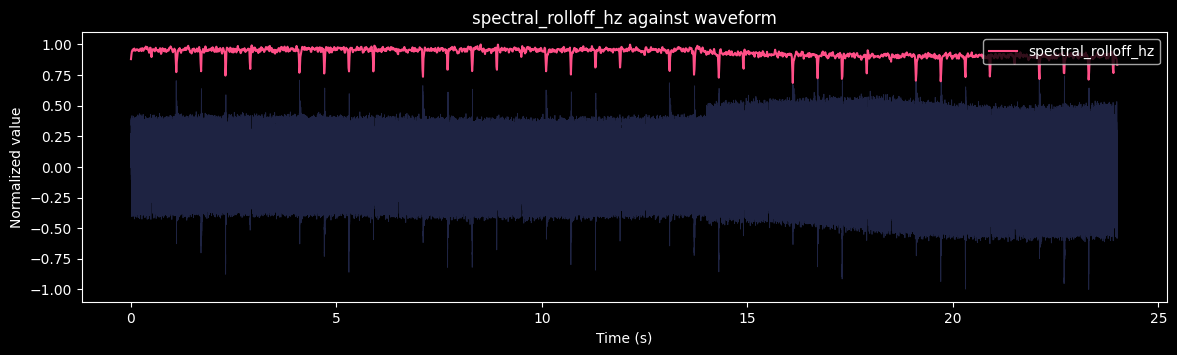

In [9]:
fig, ax = plt.subplots(figsize=(14, 3.5))
plot_feature_against_waveform(
    samples, sample_rate, features, "spectral_rolloff_hz", ax=ax
)
plt.show()


## Stage 1 Check

Before moving to onset detection, rerun this notebook with the local target WAV present and check the spectral flux plot by ear. The specific Stage 1 question is: can you point at the flux peaks and say, "those are the kick or attack events I hear"?